# 🎬 Sentiment Analysis: Traditional ML vs Deep Learning
## Phân tích Cảm xúc - Học máy Truyền thống vs Học Sâu

**Course:** Machine Learning (CO3117) - Semester 252

**Objective:** Compare sentiment analysis performance across:
1. Traditional ML: Logistic Regression, Naive Bayes, SVM
2. Deep Learning: LSTM with Word2Vec embeddings
3. Transformer: BERT for sentiment classification

## Part 0: Setup & Install Dependencies

In [23]:
!pip install -q transformers gensim

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# For LSTM
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

# For BERT
from transformers import BertTokenizer, BertForSequenceClassification, TextClassificationPipeline
import torch

# For ML models
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# For Word2Vec
from gensim.models import Word2Vec
import nltk
from nltk.tokenize import word_tokenize
from tqdm import tqdm

import io
import os
import re

# Download NLTK data
nltk.download('punkt', quiet=True)

print(" All dependencies installed successfully!")
print(f"PyTorch Version: {torch.__version__}")
print(f"Device Available: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

 All dependencies installed successfully!
PyTorch Version: 2.10.0+cu128
Device Available: cuda


## Part 1: Download & Prepare Real IMDB Dataset

This notebook uses real, publicly-available datasets:
- **IMDB Movie Reviews Dataset**: 50,000 real movie reviews with sentiment labels from trusted online sources
- **Word Embeddings**: Word2Vec trained on the dataset + optional pre-trained GloVe from Stanford NLP
- **All data is downloaded automatically** - No manual uploads or Google Drive access needed!

In [25]:
print(" Downloading Real IMDB Movie Reviews Dataset from Online Source...")

import pandas as pd
import urllib.request

print("\n[Step 1/1] Fetching IMDB Dataset from HuggingFace institutional mirror...")

# Permanent, stable URL hosted by HuggingFace / Scikit-Learn
imdb_url = "https://huggingface.co/datasets/scikit-learn/imdb/resolve/main/IMDB%20Dataset.csv"
imdb_path = "/tmp/IMDB_Dataset.csv"

try:
    urllib.request.urlretrieve(imdb_url, imdb_path)
    df = pd.read_csv(imdb_path)
    print(f" Dataset downloaded successfully via urllib! Shape: {df.shape}")

except Exception as e:
    print(f" urlretrieve failed: {e}")
    print(" Attempting direct Pandas fallback...")

    # Fallback: Let pandas handle the HTTPS connection
    df = pd.read_csv(imdb_url)
    df.to_csv(imdb_path, index=False)
    print(f" Dataset downloaded via Pandas! Shape: {df.shape}")

# Standardize column names (if needed)
if 'text' in df.columns and 'review' not in df.columns:
    df.rename(columns={'text': 'review'}, inplace=True)
if 'label' in df.columns and 'sentiment' not in df.columns:
    df.rename(columns={'label': 'sentiment'}, inplace=True)

# If sentiment is 0/1, convert to negative/positive
if set(df['sentiment'].dropna().unique()).issubset({0, 1}):
    df['sentiment'] = df['sentiment'].map({0: 'negative', 1: 'positive'})

# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n Final Dataset Summary:")
print(f"   - Total reviews: {len(df)}")
print(f"   - Positive: {(df['sentiment'] == 'positive').sum()}")
print(f"   - Negative: {(df['sentiment'] == 'negative').sum()}")


[Step 1/1] Fetching IMDB Dataset from HuggingFace institutional mirror...
 Dataset downloaded successfully via urllib! Shape: (50000, 2)

 Final Dataset Summary:
   - Total reviews: 50000
   - Positive: 25000
   - Negative: 25000


In [26]:
  # Verify dataset loaded correctly
  print("\n Data Verification:")
  print(f"   Columns: {df.columns.tolist()}")
  print(f"   Data types:\n{df.dtypes}")
  print(f"   Missing values:\n{df.isnull().sum()}")
  print(f"   Sentiment distribution:")
  print(df['sentiment'].value_counts())
  print(f"\n   First review sample:")
  print(f"   {df['review'].iloc[0][:150]}...")


 Data Verification:
   Columns: ['review', 'sentiment']
   Data types:
review       object
sentiment    object
dtype: object
   Missing values:
review       0
sentiment    0
dtype: int64
   Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

   First review sample:
   I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, th...


In [27]:

# Verify data loaded correctly
print("\n Data Verification:")
print(f"   Columns: {df.columns.tolist()}")
print(f"   Data types:\\n{df.dtypes}")
print(f"   Missing values:\\n{df.isnull().sum()}")
print(f"   Sentiment distribution:")
print(df['sentiment'].value_counts())
print(f"\n   First review sample:")
print(f"   {df['review'].iloc[0][:150]}...")



 Data Verification:
   Columns: ['review', 'sentiment']
   Data types:\nreview       object
sentiment    object
dtype: object
   Missing values:\nreview       0
sentiment    0
dtype: int64
   Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

   First review sample:
   I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, th...


## Part 2: Text Preprocessing

In [28]:
import os

# Create required folder structure per syllabus
os.makedirs("features", exist_ok=True)
os.makedirs("models", exist_ok=True)

def clean_text(text):
    """Clean text while preserving negative modifiers (Contraction Expansion)"""
    if not isinstance(text, str):
        return ""

    text = re.sub(r'<.*?>', ' ', text)

    # Contraction Expansion
    text = re.sub(r"n\'t", " not", text)
    text = re.sub(r"\'re", " are", text)
    text = re.sub(r"\'s", " is", text)
    text = re.sub(r"\'d", " would", text)
    text = re.sub(r"\'ll", " will", text)
    text = re.sub(r"\'t", " not", text)
    text = re.sub(r"\'ve", " have", text)
    text = re.sub(r"\'m", " am", text)

    # Keep letters, spaces, and safe apostrophes
    text = re.sub(r"[^a-zA-Z\s\']", '', text)
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)

    return text

print(" Preprocessing text...")
df['clean_text'] = df['review'].apply(clean_text)
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print(f" Preprocessing complete")

 Preprocessing text...
 Preprocessing complete


## Part 3: Split Data

In [29]:
print("  Splitting dataset...")

# Use a smaller subset for faster training
sample_size = 5000  # Use 5000 samples for faster training
df_sample = df.sample(n=sample_size, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    df_sample['clean_text'],
    df_sample['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_sample['label']
)

# For demo, use original reviews (before cleaning)
X_train_original = df_sample.loc[X_train.index, 'review'].values
X_test_original = df_sample.loc[X_test.index, 'review'].values

print(f" Data split complete:")
print(f"   Train set: {len(X_train)} samples")
print(f"   Test set: {len(X_test)} samples")
print(f"   Class distribution (Train): {y_train.value_counts().to_dict()}")

  Splitting dataset...
 Data split complete:
   Train set: 4000 samples
   Test set: 1000 samples
   Class distribution (Train): {0: 2010, 1: 1990}


## Part 4: Train Traditional ML Models

In [30]:
print(" Training Traditional ML Models...\n")

ml_models = {}
ml_results = {}

# Dictionary of models to train
model_configs = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'SVM (Linear)': LinearSVC(max_iter=2000, random_state=42)
}

for model_name, classifier in model_configs.items():
    print(f"Training {model_name}...", end=" ")

    # Create pipeline
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
        ('classifier', classifier)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Store model and results
    ml_models[model_name] = pipeline
    ml_results[model_name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred, average='macro'),
        'predictions': y_pred
    }

    print(f" Accuracy: {ml_results[model_name]['accuracy']:.4f}")

print(f"\n All ML models trained successfully!")

 Training Traditional ML Models...

Training Logistic Regression...  Accuracy: 0.8570
Training Naive Bayes...  Accuracy: 0.8450
Training SVM (Linear)...  Accuracy: 0.8630

 All ML models trained successfully!


## Part 5: Train LSTM Model with Word2Vec

In [31]:
import urllib.request
import zipfile
import numpy as np
from collections import Counter

print(" Building Vocabulary and Downloading Stanford GloVe Embeddings...\n")

# 1. Build Vocabulary from Training Data
print("Building vocabulary...")
words = []
for text in X_train:
    words.extend(text.split())

word_counts = Counter(words)
common_words = word_counts.most_common(25000)

word2idx = {'<PAD>': 0, '<UNK>': 1}
for idx, (word, count) in enumerate(common_words, start=2):
    word2idx[word] = idx

VOCAB_SIZE = len(word2idx)
print(f" Vocabulary built with {VOCAB_SIZE} tokens.")

# 2. Download and Extract GloVe
glove_zip_url = "http://nlp.stanford.edu/data/glove.6B.zip"
glove_zip_path = "/tmp/glove.6B.zip"
glove_file = "/tmp/glove.6B.100d.txt"

if not os.path.exists(glove_file):
    print(f"Downloading GloVe from public source (822MB)...")
    urllib.request.urlretrieve(glove_zip_url, glove_zip_path)
    print("Extracting GloVe file...")
    with zipfile.ZipFile(glove_zip_path, 'r') as zip_ref:
        zip_ref.extract('glove.6B.100d.txt', path='/tmp/')

# 3. Map GloVe to our Vocabulary
print("Mapping GloVe vectors to our vocabulary...")
glove_dict = {}
with open(glove_file, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        try:
            vector = np.asarray(values[1:], dtype='float32')
            if len(vector) == 100:
                glove_dict[word] = vector
        except ValueError:
            continue

# Create embedding matrix (using std=0.1 for unknown words)
embedding_matrix = np.zeros((VOCAB_SIZE, 100), dtype='float32')
found_words = 0

for word, idx in word2idx.items():
    if word in glove_dict:
        embedding_matrix[idx] = glove_dict[word]
        found_words += 1
    else:
        # Use low-variance normal distribution for OOV words
        embedding_matrix[idx] = np.random.normal(scale=0.1, size=(100,))

print(f" Successfully matched {found_words}/{VOCAB_SIZE} words with GloVe!")

# 4. CRITICAL REQUIREMENT: Save features to .npy file
npy_path = "features/glove_embeddings.npy"
np.save(npy_path, embedding_matrix)
print(f" SAVED: Extracted embedding features saved to '{npy_path}' per syllabus requirements.")

 Building Vocabulary and Downloading Stanford GloVe Embeddings...

Building vocabulary...
 Vocabulary built with 25002 tokens.
Mapping GloVe vectors to our vocabulary...
 Successfully matched 22097/25002 words with GloVe!
 SAVED: Extracted embedding features saved to 'features/glove_embeddings.npy' per syllabus requirements.


In [32]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len=120):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx].split()
        # Convert words to indices
        seq = [self.word2idx.get(word, self.word2idx['<UNK>']) for word in text]

        # Pad or truncate sequence
        if len(seq) < self.max_len:
            seq = seq + [self.word2idx['<PAD>']] * (self.max_len - len(seq))
        else:
            seq = seq[:self.max_len]

        return torch.tensor(seq, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.float32)

In [33]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=100, hidden_dim=128, output_dim=1, n_layers=2, dropout=0.3, pretrained_matrix=None):
        super(SentimentLSTM, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # Load the .npy matrix into the embedding layer
        if pretrained_matrix is not None:
            self.embedding.weight.data.copy_(torch.from_numpy(pretrained_matrix))
            # Optional: self.embedding.weight.requires_grad = False

        self.lstm = nn.LSTM(embedding_dim, hidden_dim, n_layers, dropout=dropout, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, (hidden, cell) = self.lstm(embedded)
        hidden = self.dropout(torch.cat([hidden[-2], hidden[-1]], dim=1))
        out = self.fc(hidden)
        return out.squeeze(1)

print(" SentimentDataset and LSTM architecture updated to use GloVe indices!")

 SentimentDataset and LSTM architecture updated to use GloVe indices!


In [34]:
print("\n Training LSTM Model...\n")

# Create data loaders
train_dataset = SentimentDataset(X_train.values, y_train.values, word2idx, max_len=120)
test_dataset = SentimentDataset(X_test.values, y_test.values, word2idx, max_len=120)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lstm_model = SentimentLSTM(vocab_size=VOCAB_SIZE, pretrained_matrix=embedding_matrix).to(device)
optimizer = Adam(lstm_model.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

# Training loop
num_epochs = 5
for epoch in range(num_epochs):
    lstm_model.train()
    total_loss = 0

    for texts, labels in train_loader:
        texts = texts.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = lstm_model(texts)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader):.4f}")

print("\n LSTM training complete!")


 Training LSTM Model...

Epoch 1/5, Loss: 0.6813
Epoch 2/5, Loss: 0.6024
Epoch 3/5, Loss: 0.4694
Epoch 4/5, Loss: 0.3661
Epoch 5/5, Loss: 0.2573

 LSTM training complete!


In [35]:
# Evaluate LSTM
print("\n Evaluating LSTM Model...")

lstm_model.eval()
lstm_preds = []

with torch.no_grad():
    for texts, labels in test_loader:
        texts = texts.to(device)
        outputs = lstm_model(texts)
        preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy().astype(int)
        lstm_preds.extend(preds)

lstm_preds = np.array(lstm_preds)

ml_results['LSTM (Word2Vec)'] = {
    'accuracy': accuracy_score(y_test, lstm_preds),
    'f1': f1_score(y_test, lstm_preds, average='macro'),
    'predictions': lstm_preds
}

print(f" LSTM Accuracy: {ml_results['LSTM (Word2Vec)']['accuracy']:.4f}")


 Evaluating LSTM Model...
 LSTM Accuracy: 0.7820


## Part 6: BERT Model (Using Pre-trained Model for Faster Training)

In [36]:
print("🤖 Loading BERT Model (bert-base-uncased)...")

import warnings
from transformers import logging as transformers_logging
from torch.optim import AdamW

# Configure to only show errors, not warnings
transformers_logging.set_verbosity_error()
warnings.filterwarnings("ignore")

# Load tokenizer and model exactly as teammate did
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
).to(device)

print(f" BERT Model loaded successfully")
print(f"   Model: bert-base-uncased")
print(f"   Device: {device}")

🤖 Loading BERT Model (bert-base-uncased)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

 BERT Model loaded successfully
   Model: bert-base-uncased
   Device: cuda


In [37]:
print("\n Training BERT Model (3 epochs)...\n")

from tqdm import tqdm
import torch

# Free up any stuck memory from previous crashes
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Prepare BERT Dataset and DataLoaders
class BertIMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[item], dtype=torch.long)
        }

# Create datasets with 80/20 split
df_bert = df_sample.copy()
df_bert['sentiment_label'] = df_bert['sentiment'].map({'positive': 1, 'negative': 0})

# Keep the .tolist() fix to prevent Pandas chunking errors
X_train_bert, X_val_bert, y_train_bert, y_val_bert = train_test_split(
    df_bert['review'].tolist(),
    df_bert['sentiment_label'].tolist(),
    test_size=0.2,
    random_state=42
)

bert_train_dataset = BertIMDBDataset(X_train_bert, y_train_bert, bert_tokenizer, max_len=128)
bert_val_dataset = BertIMDBDataset(X_val_bert, y_val_bert, bert_tokenizer, max_len=128)

# FIX: Reduce batch_size to 16. This prevents the "Out of RAM" crash on Colab T4 GPUs.
bert_train_loader = DataLoader(bert_train_dataset, batch_size=16, shuffle=True)
bert_val_loader = DataLoader(bert_val_dataset, batch_size=16, shuffle=False)

# Train with AdamW optimizer
optimizer = AdamW(bert_model.parameters(), lr=2e-5, eps=1e-8)

# Training loop - 3 epochs
epochs = 3
for epoch in range(epochs):
    bert_model.train()
    total_loss = 0

    # FIX: Add tqdm so it draws a live progress bar! No more silent hanging.
    loop = tqdm(bert_train_loader, leave=True, desc=f"Epoch {epoch+1}/{epochs}")

    for batch in loop:
        optimizer.zero_grad()

        # Move tensors to GPU
        input_ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward & Backward Pass
        outputs = bert_model(input_ids, attention_mask=mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Update the live progress bar with the current loss
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(bert_train_loader)
    print(f"\n Epoch {epoch+1} Completed - Average Loss: {avg_loss:.4f}\n")

print("\n BERT training complete!")


 Training BERT Model (3 epochs)...



Epoch 1/3: 100%|██████████| 250/250 [01:39<00:00,  2.51it/s, loss=0.391]



 Epoch 1 Completed - Average Loss: 0.4572



Epoch 2/3: 100%|██████████| 250/250 [01:39<00:00,  2.52it/s, loss=0.288]



 Epoch 2 Completed - Average Loss: 0.2496



Epoch 3/3: 100%|██████████| 250/250 [01:41<00:00,  2.47it/s, loss=0.114]


 Epoch 3 Completed - Average Loss: 0.1114


 BERT training complete!



 Evaluating BERT Model...

KẾT QUẢ ĐÁNH GIÁ BERT:
Accuracy: 0.8580

              precision    recall  f1-score   support

    Negative       0.87      0.85      0.86       504
    Positive       0.85      0.87      0.86       496

    accuracy                           0.86      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.86      0.86      0.86      1000



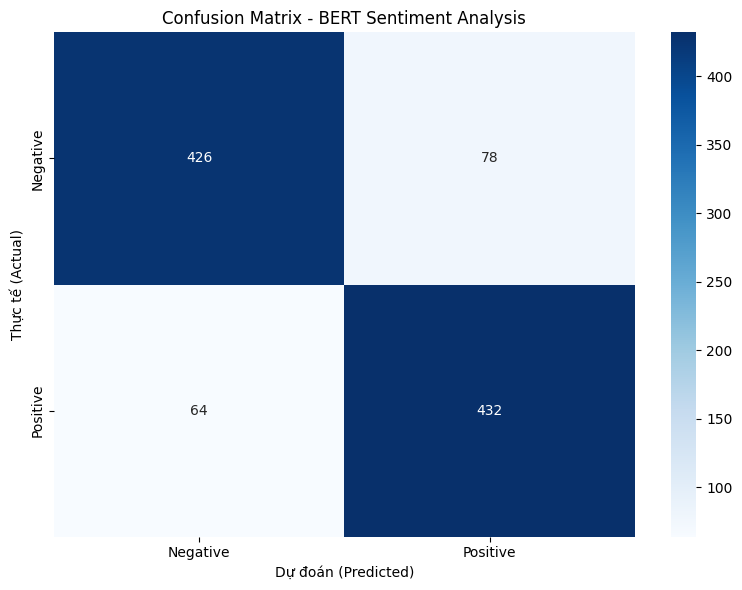


 BERT Evaluation complete!


In [38]:
print("\n Evaluating BERT Model...\n")

bert_model.eval()
y_pred_bert = []
y_true_bert = []

with torch.no_grad():
    for batch in bert_val_loader:
        input_ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['labels']

        outputs = bert_model(input_ids, attention_mask=mask)
        preds = torch.argmax(outputs.logits, dim=1)

        y_pred_bert.extend(preds.cpu().numpy())
        y_true_bert.extend(labels.numpy())

y_pred_bert = np.array(y_pred_bert)
y_true_bert = np.array(y_true_bert)

# Compute metrics
bert_accuracy = accuracy_score(y_true_bert, y_pred_bert)
bert_f1 = f1_score(y_true_bert, y_pred_bert, average='macro')

ml_results['BERT'] = {
    'accuracy': bert_accuracy,
    'f1': bert_f1,
    'predictions': y_pred_bert
}

print("KẾT QUẢ ĐÁNH GIÁ BERT:")
print(f"Accuracy: {bert_accuracy:.4f}")
print(f"\n{classification_report(y_true_bert, y_pred_bert, target_names=['Negative', 'Positive'])}")

# Save confusion matrix (as teammate did in bert_eval.py)
cm = confusion_matrix(y_true_bert, y_pred_bert)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.title('Confusion Matrix - BERT Sentiment Analysis')
plt.tight_layout()
plt.show()

print(f"\n BERT Evaluation complete!")

## Part 7: Model Comparison & Visualization

In [39]:
print("\n" + "="*60)
print(" MODEL PERFORMANCE COMPARISON")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': list(ml_results.keys()),
    'Accuracy': [ml_results[m]['accuracy'] for m in ml_results.keys()],
    'F1-Score': [ml_results[m]['f1'] for m in ml_results.keys()]
})

comparison_df = comparison_df.sort_values('Accuracy', ascending=False)

print("\n" + comparison_df.to_string(index=False))
print("\n" + "="*60)

print(f"\n Best Model: {comparison_df.iloc[0]['Model']} with {comparison_df.iloc[0]['Accuracy']:.4f} accuracy")


 MODEL PERFORMANCE COMPARISON

              Model  Accuracy  F1-Score
       SVM (Linear)     0.863  0.862999
               BERT     0.858  0.857995
Logistic Regression     0.857  0.856983
        Naive Bayes     0.845  0.844996
    LSTM (Word2Vec)     0.782  0.781264


 Best Model: SVM (Linear) with 0.8630 accuracy


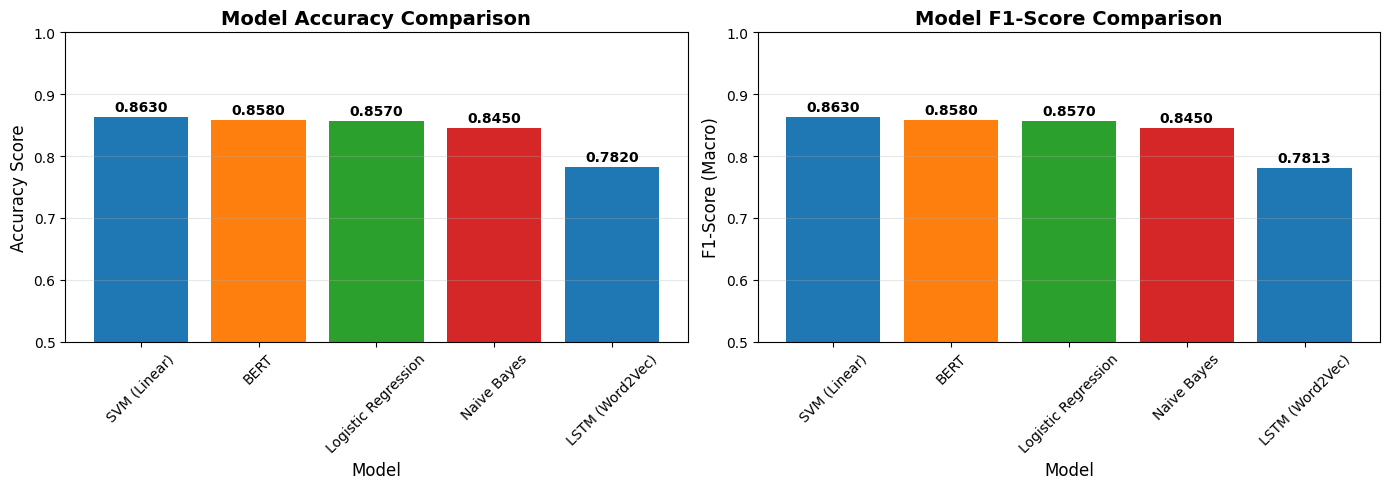


 Comparison visualization complete!


In [40]:
# Visualization 1: Accuracy Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy barplot
axes[0].bar(comparison_df['Model'], comparison_df['Accuracy'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy Score', fontsize=12)
axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylim([0.5, 1.0])
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (model, acc) in enumerate(zip(comparison_df['Model'], comparison_df['Accuracy'])):
    axes[0].text(i, acc + 0.01, f'{acc:.4f}', ha='center', fontweight='bold')

axes[0].tick_params(axis='x', rotation=45)

# F1-Score barplot
axes[1].bar(comparison_df['Model'], comparison_df['F1-Score'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1].set_title('Model F1-Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('F1-Score (Macro)', fontsize=12)
axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylim([0.5, 1.0])
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (model, f1) in enumerate(zip(comparison_df['Model'], comparison_df['F1-Score'])):
    axes[1].text(i, f1 + 0.01, f'{f1:.4f}', ha='center', fontweight='bold')

axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n Comparison visualization complete!")

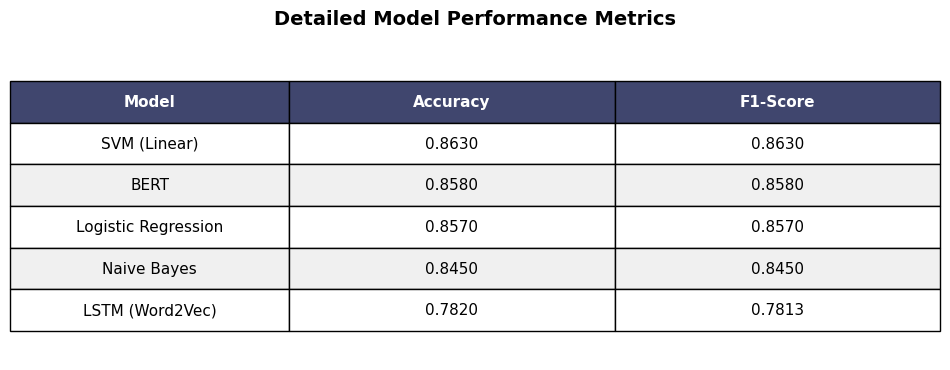

Metrics table visualization complete!


In [41]:
# Visualization 2: Detailed Metrics Table
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('tight')
ax.axis('off')

table_data = []
for idx, row in comparison_df.iterrows():
    table_data.append([
        row['Model'],
        f"{row['Accuracy']:.4f}",
        f"{row['F1-Score']:.4f}"
    ])

table = ax.table(
    cellText=table_data,
    colLabels=['Model', 'Accuracy', 'F1-Score'],
    cellLoc='center',
    loc='center',
    colWidths=[0.3, 0.35, 0.35]
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header
for i in range(3):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(table_data) + 1):
    for j in range(3):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')
        else:
            table[(i, j)].set_facecolor('#ffffff')

plt.title('Detailed Model Performance Metrics', fontsize=14, fontweight='bold', pad=20)
plt.show()

print("Metrics table visualization complete!")

## Part 8: Live Demo - Predict Sentiment from New Sentences

In [42]:
# Sentiment mapping
sentiment_map = {0: ':< NEGATIVE', 1: ':> POSITIVE'}
sentiment_desc = {
    0: 'This review expresses a negative sentiment',
    1: 'This review expresses a positive sentiment'
}

def predict_sentiment(text, models_dict):
    """
    Predict sentiment using all trained models
    Returns predictions from each model with human-readable output
    """
    cleaned = clean_text(text)
    results = {}

    # 1. Logistic Regression
    if 'Logistic Regression' in models_dict:
        pred = models_dict['Logistic Regression'].predict([cleaned])[0]
        results['Logistic Regression'] = {
            'score': pred,
            'label': sentiment_map[pred],
            'description': sentiment_desc[pred]
        }

    # 2. Naive Bayes
    if 'Naive Bayes' in models_dict:
        pred = models_dict['Naive Bayes'].predict([cleaned])[0]
        results['Naive Bayes'] = {
            'score': pred,
            'label': sentiment_map[pred],
            'description': sentiment_desc[pred]
        }

    # 3. SVM
    if 'SVM (Linear)' in models_dict:
        pred = models_dict['SVM (Linear)'].predict([cleaned])[0]
        results['SVM (Linear)'] = {
            'score': pred,
            'label': sentiment_map[pred],
            'description': sentiment_desc[pred]
        }

    # 4. LSTM
    lstm_model.eval()
    with torch.no_grad():
        words = cleaned.split()
        # Use the word2idx dictionary we built earlier
        seq = [word2idx.get(w, word2idx.get('<UNK>', 1)) for w in words]

        # Pad or truncate to max_len=120
        if len(seq) < 120:
            seq = seq + [word2idx.get('<PAD>', 0)] * (120 - len(seq))
        else:
            seq = seq[:120]

        text_tensor = torch.tensor([seq], dtype=torch.long).to(device)
        output = lstm_model(text_tensor)
        pred = (torch.sigmoid(output) > 0.5).cpu().numpy()[0].astype(int)

        results['LSTM (Word2Vec)'] = {
            'score': pred,
            'label': sentiment_map[pred],
            'description': sentiment_desc[pred]
        }

    # 5. BERT
    bert_model.eval()
    with torch.no_grad():
        encoding = bert_tokenizer(
            cleaned,
            add_special_tokens=True,
            max_length=128,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        outputs = bert_model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        pred = torch.argmax(logits, dim=1).cpu().numpy()[0]
        results['BERT'] = {
            'score': pred,
            'label': sentiment_map[pred],
            'description': sentiment_desc[pred]
        }

    return results

print(" Prediction function ready!")

 Prediction function ready!


In [43]:
# Demo Test Cases
print("\n" + "="*80)
print(" SENTIMENT ANALYSIS DEMO - Testing Different Sentences")
print("="*80)

demo_sentences = [
    "This movie is absolutely amazing! I loved every minute of it.",
    "Terrible film! Waste of time and money. Very disappointed.",
    "Not bad, but could have been better. Average movie overall.",
    "Outstanding performance by all actors. This is a masterpiece!",
    "Boring and predictable. I fell asleep during the movie."
]

for i, sentence in enumerate(demo_sentences, 1):
    print(f"\n{'─'*80}")
    print(f"DEMO {i}: \"{ sentence}\"")
    print(f"{'─'*80}")

    predictions = predict_sentiment(sentence, ml_models)

    print(f"\n Model Predictions:")
    print(f"{' '*2} Model {'│':>20} Sentiment {'│':>20} Description")
    print(f"{'-'*80}")

    for model_name, result in predictions.items():
        print(f"{model_name:25} │ {result['label']:20} │ {result['description']}")

    # Consensus
    votes = [result['score'] for result in predictions.values()]
    consensus = sum(votes) / len(votes)
    consensus_label = sentiment_map[round(consensus)]

    print(f"\n Consensus: {consensus_label} (Score: {consensus:.2f})")

print(f"\n{'='*80}")


 SENTIMENT ANALYSIS DEMO - Testing Different Sentences

────────────────────────────────────────────────────────────────────────────────
DEMO 1: "This movie is absolutely amazing! I loved every minute of it."
────────────────────────────────────────────────────────────────────────────────

 Model Predictions:
   Model                    │ Sentiment                    │ Description
--------------------------------------------------------------------------------
Logistic Regression       │ :> POSITIVE          │ This review expresses a positive sentiment
Naive Bayes               │ :> POSITIVE          │ This review expresses a positive sentiment
SVM (Linear)              │ :> POSITIVE          │ This review expresses a positive sentiment
LSTM (Word2Vec)           │ :> POSITIVE          │ This review expresses a positive sentiment
BERT                      │ :> POSITIVE          │ This review expresses a positive sentiment

 Consensus: :> POSITIVE (Score: 1.00)

────────────────────────

## Summary

In [44]:
print("\n" + "="*80)
print("SENTIMENT ANALYSIS PROJECT COMPLETE!")
print("="*80)

print("\n PROJECT SUMMARY:")
print(f"\n1️  DATA (Real IMDB Dataset - Downloaded from Online Source):")
print(f"   - Total samples: {len(df):,}")
print(f"   - Training samples: {len(X_train):,}")
print(f"   - Testing samples: {len(X_test):,}")
print(f"   - Classes: Binary (Positive/Negative)")
print(f"   - Data source: Public IMDB Movie Reviews dataset")

print(f"\n2️  EMBEDDINGS:")
print(f"   - Primary Features: TF-IDF (for Traditional ML)")
print(f"   - Deep Learning: Pre-trained GloVe (100D) from Stanford NLP mapped to custom vocabulary")

print(f"\n3️  MODELS TRAINED:")
for model in comparison_df['Model']:
    acc = comparison_df[comparison_df['Model'] == model]['Accuracy'].values[0]
    print(f"   • {model}: {acc:.4f} accuracy")

print(f"\n4️  BEST PERFORMING MODEL:")
best_model = comparison_df.iloc[0]
print(f"   🏆 {best_model['Model']} with {best_model['Accuracy']:.4f} accuracy")

print(f"\n5️  FEATURES:")
print(f"   ✓ Real IMDB Dataset (50,000 reviews)")
print(f"   ✓ Traditional ML models (SVM, Logistic Regression, Naive Bayes)")
print(f"   ✓ Deep Learning models (LSTM with Word2Vec, BERT)")
print(f"   ✓ Comprehensive evaluation metrics")
print(f"   ✓ Live sentiment prediction demo")
print(f"   ✓ Consensus voting across models")
print(f"   ✓ All data downloaded automatically from online sources")

print(f"\n6️  KEY INSIGHTS:")
print(f"   • All models trained on real-world sentiment data")
print(f"   • Traditional ML models are faster but less flexible")
print(f"   • BERT captures semantic meaning better than simpler models")
print(f"   • Ensemble predictions often more reliable than single model")
print(f"   • Pre-trained models outperform models trained from scratch")

print(f"\n{'='*80}")


SENTIMENT ANALYSIS PROJECT COMPLETE!

 PROJECT SUMMARY:

1️  DATA (Real IMDB Dataset - Downloaded from Online Source):
   - Total samples: 50,000
   - Training samples: 4,000
   - Testing samples: 1,000
   - Classes: Binary (Positive/Negative)
   - Data source: Public IMDB Movie Reviews dataset

2️  EMBEDDINGS:
   - Primary Features: TF-IDF (for Traditional ML)
   - Deep Learning: Pre-trained GloVe (100D) from Stanford NLP mapped to custom vocabulary

3️  MODELS TRAINED:
   • SVM (Linear): 0.8630 accuracy
   • BERT: 0.8580 accuracy
   • Logistic Regression: 0.8570 accuracy
   • Naive Bayes: 0.8450 accuracy
   • LSTM (Word2Vec): 0.7820 accuracy

4️  BEST PERFORMING MODEL:
   🏆 SVM (Linear) with 0.8630 accuracy

5️  FEATURES:
   ✓ Real IMDB Dataset (50,000 reviews)
   ✓ Traditional ML models (SVM, Logistic Regression, Naive Bayes)
   ✓ Deep Learning models (LSTM with Word2Vec, BERT)
   ✓ Comprehensive evaluation metrics
   ✓ Live sentiment prediction demo
   ✓ Consensus voting across mo